In [2]:
import rich
import logging
import glob

import matplotlib.pyplot as plt
import time
import os
import awkward as ak
import numpy as np
import pandas as pd
from lgdo import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data

%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.12/site-packages/tornado

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



# Path to data

In [3]:
data_path = "/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/v2.1.5"
config = Props.read_from(os.path.join(data_path, "config.json"), subst_pathvar=True)["setups"]["l200"]["paths"]
meta  = LegendMetadata(config["metadata"])
chmap = meta.channelmap(meta.dataprod.runinfo.p03.r000.phy.start_key)

# mask for detector type

In [4]:
chmap_ak = ak.Array(meta.channelmap(meta.dataprod.runinfo.p03.r000.phy.start_key).group("system").geds.values())

In [5]:
rawids = ak.to_numpy(chmap_ak.daq.rawid)

names = ak.to_numpy(chmap_ak["name"]).astype(str)

masks_name = {
    "ICPC": np.char.startswith(names, "V"),
    "BEGe": np.char.startswith(names, "B"),
    "Coax": np.char.startswith(names, "C"),
    "PPC":  np.char.startswith(names, "P"),
}

In [6]:
rawids = ak.to_numpy(chmap_ak.daq.rawid)

channels_rawid = {
    det_type: [f"ch{rid}" for rid in rawids[mask]]
    for det_type, mask in masks_name.items()
}

channels_names = {
    det_type: [f"{name}" for name in names[mask]]
    for det_type, mask in masks_name.items()
}

# Get files

In [7]:
print(channels_rawid["BEGe"][0])
print(channels_names["BEGe"][0])

ch1107202
B00035C


In [8]:
detector = "V02160A"
name = channels_names["ICPC"][0]
chn = chmap[f'{name}'].daq.rawid  # seleziono un detector

channel = f'ch{chn}'

In [9]:
# tutti questi file non hanno nulla a che vedere con il canale. ci sono tutte le informazioni di tutti i periodi e run
pet_files = sorted(glob.glob(f"{config['tier_pet']}/phy/l200-p0[346789]-*-phy-tier_pet.lh5"))

In [10]:
# sempre sorted list
psp_files = sorted(glob.glob(f"{config["tier_psp"]}/cal/p03/r000/*.lh5")) #access exsiting DSP-processed data such as the energy for partitions
tcm_files = sorted(glob.glob(f"{config["tier_tcm"]}/cal/p03/r000/*.lh5"))  # --> solo per il pulse
raw_files = sorted(glob.glob(f"{config["tier_raw"]}/cal/p03/r000/*.lh5"))
cal_file = f"{config["par_pht"]}/cal/p03/r000/l200-p03-r000-cal-20230311T235840Z-par_pht.json"

# PSP files

In [11]:
# qui posso scriveere tutti i parametri che voglio vengano restituiti/salvati dal path di PSP
params = [ 't_sat_lo',
        "bl_slope",
    "cuspEmax_ctc_cal",
    "is_valid_bl_slope",
    "is_valid_cal"
    ]


In [12]:
#cal_dict = Props.read_from(cal_file)[channel_bege]["pars"]["operations"]
cal = Props.read_from(cal_file)

# questi sono i file id calibrazione di tutti i detector che abbiamo
print(cal.keys());

dict_keys(['ch1104000', 'ch1104001', 'ch1104002', 'ch1104003', 'ch1104004', 'ch1104005', 'ch1105600', 'ch1105602', 'ch1105603', 'ch1107202', 'ch1107203', 'ch1107204', 'ch1107205', 'ch1108800', 'ch1108801', 'ch1108802', 'ch1108803', 'ch1110402', 'ch1110403', 'ch1110404', 'ch1112000', 'ch1112001', 'ch1112002', 'ch1112003', 'ch1112004', 'ch1112005', 'ch1113600', 'ch1113601', 'ch1113602', 'ch1113603', 'ch1113604', 'ch1113605', 'ch1115203', 'ch1115204', 'ch1116801', 'ch1116802', 'ch1116803', 'ch1116804', 'ch1116805', 'ch1118402', 'ch1118403', 'ch1118404', 'ch1118405', 'ch1120000', 'ch1120001', 'ch1120002', 'ch1120003', 'ch1120004', 'ch1120005', 'ch1121600', 'ch1121601', 'ch1121602', 'ch1121603', 'ch1121604', 'ch1121605', 'ch1078400', 'ch1078405', 'ch1080000', 'ch1080001', 'ch1080004', 'ch1080005', 'ch1081600', 'ch1081601', 'ch1081602', 'ch1081603', 'ch1081604', 'ch1081605', 'ch1083201', 'ch1083202', 'ch1083203', 'ch1083204', 'ch1083205', 'ch1084800', 'ch1084801', 'ch1084802', 'ch1084803', '

channels = [ f'ch{chmap.V02160A.daq.rawid}', f'ch{chmap.B00032A.daq.rawid}']

In [13]:
# qui mi posso salvare i paramteri di DSP (che ho scelto e definito in config) per lo specfico canale e per tutti gli eventi registrati
data, threshold_masks= load_data(
        files = psp_files,
        lh5_path = f"{channel}/dsp",
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"],
        params=params,
        #threshold=500,
        return_selection_mask=True,)

In [14]:
# funzione ch emi perfmette di rimuovere il pulser : quello che fa è che 
# 1. mi restituisce tranite la coincidenza temporale un array di elementi boolenai ch emi dicono se l'evento è stato in coincidenza ( e quindi è ) con un pulser
# 2. mi aggiunge una colonna al mio data frame (colonna di Bool )

pulser_ids, mask = get_tcm_pulser_ids(tcm_files, channel, 5) # pulser removal
data["is_pulser"] = mask

# Energy 

In [15]:
data;

In [16]:
e_cal = data.query("~is_pulser")["cuspEmax_ctc_cal"]
e_cal_valid = data.query("~is_pulser&is_valid_cal")["cuspEmax_ctc_cal"]
e_puls = data.query("is_pulser&is_valid_cal")["cuspEmax_ctc_cal"]

In [17]:
mask_discharge = data['t_sat_lo']>0
data["is_discharge"] = mask_discharge



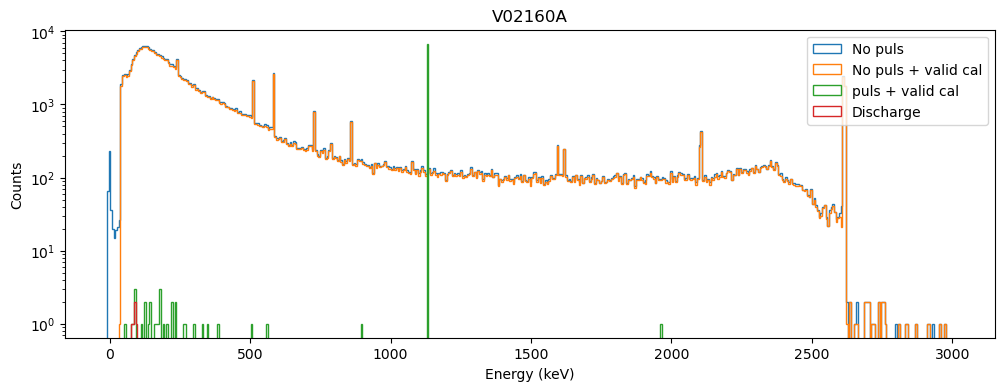

In [18]:
plt.figure(figsize = (12,4))
plt.hist(e_cal, bins = 500, range = (-10, 3000), histtype = 'step', label = 'No puls')
plt.hist(e_cal_valid, bins = 500, range = (-10, 3000), histtype = 'step', label = 'No puls + valid cal')
plt.hist(e_puls, bins = 500, range = (-10, 3000), histtype = 'step', label = 'puls + valid cal')
plt.hist( data.query("is_discharge")["cuspEmax_ctc_cal"], bins = 500, range = (-10, 3000), histtype = 'step', label = 'Discharge')
plt.legend(loc = 'upper right')
plt.ylabel(f"Counts")
plt.xlabel(f"Energy (keV)")
plt.title(f"{detector}")
plt.yscale('log')


# Slope

In [19]:
# da questo momento in poi tolgo sempre la scaricva

In [20]:
cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]

In [21]:
data;

In [22]:
mask_lowe = data["cuspEmax_ctc_cal"] < 500
data["is_below_500keV"] = mask_lowe
data;

In [23]:
data["is_below_500keV"];

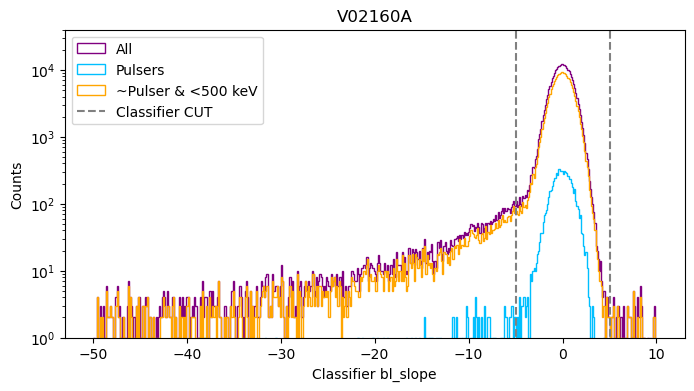

In [24]:
a_class = cal_dict["is_valid_bl_slope_classifier"]['parameters']['a']
b_class = cal_dict["is_valid_bl_slope_classifier"]['parameters']['b']

plt.figure(figsize = (8,4))
plt.hist((data.query("~is_discharge")["bl_slope"]-a_class)/b_class, bins = 500, range = (-50,10), color = 'purple', histtype = 'step', label = 'All')
plt.hist((data.query("is_pulser")["bl_slope"]-a_class)/b_class, bins = 500, range = (-50,10), color = "deepskyblue", histtype = 'step', label = 'Pulsers')
plt.hist((data.query("~is_discharge&~is_pulser&is_below_500keV")["bl_slope"]-a_class)/b_class, bins = 500, range = (-50,10), color = "orange", histtype = 'step', label = '~Pulser & <500 keV')
#plt.hist((data.query("is_below_500keV")["bl_slope"]-a_class)/b_class, bins = 500, range = (-10,10), histtype = 'step', label = '<500 KeV')
#plt.hist((data.query("~is_pulser")["bl_slope"][e_cal<500]-a_class)/b_class, bins = 500, range = (-1,1), histtype = 'step', label = '< 500 kev')
plt.vlines(-5, 0, 1e5, ls = '--', color = 'grey' )
plt.vlines(5, 0, 1e5, ls = '--', color = 'grey', label = 'Classifier CUT' )
plt.ylim(1, 4e4)
plt.legend(loc = 'upper left')
plt.ylabel(f"Counts")
plt.xlabel(f"Classifier bl_slope")
plt.title(f"{detector}")
plt.yscale('log')
plt.savefig("bl_slope_class.svg", dpi = 600)

In [25]:
classifier = (data["bl_slope"] - a_class) / b_class

mask_class = (classifier > cal_dict["is_valid_bl_slope"]["parameters"]["a"]) & \
       (classifier < cal_dict["is_valid_bl_slope"]["parameters"]["b"])

data["is_valid_classifier_bl_slope"] = mask_class

In [26]:
data["is_valid_classifier_bl_slope"];

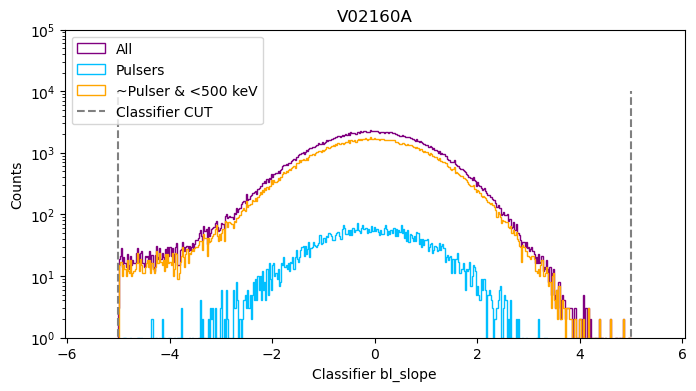

In [27]:

plt.figure(figsize = (8,4))
plt.hist((data.query("~is_discharge&is_valid_classifier_bl_slope")["bl_slope"]-a_class)/b_class, bins = 500, range = (-5.5, 5.5), color = 'purple', histtype = 'step', label = 'All')
plt.hist((data.query("~is_discharge&is_pulser&is_valid_classifier_bl_slope")["bl_slope"]-a_class)/b_class, bins = 500, range = ( -5.5, 5.5), color = "deepskyblue", histtype = 'step', label = 'Pulsers')
plt.hist((data.query("~is_discharge&~is_pulser&is_below_500keV&is_valid_classifier_bl_slope")["bl_slope"]-a_class)/b_class, bins = 500, range = (-5.5, 5.5), color = "orange", histtype = 'step', label = '~Pulser & <500 keV')
#plt.hist((data.query("is_below_500keV")["bl_slope"]-a_class)/b_class, bins = 500, range = (-10,10), histtype = 'step', label = '<500 KeV')
#plt.hist((data.query("~is_pulser")["bl_slope"][e_cal<500]-a_class)/b_class, bins = 500, range = (-1,1), histtype = 'step', label = '< 500 kev')
plt.vlines(-5, 0, 1e4, ls = '--', color = 'grey' )
plt.vlines(5, 0, 1e4, ls = '--', color = 'grey', label = 'Classifier CUT' )
plt.ylim(1, 1e5)
plt.legend(loc = 'upper left')
plt.ylabel(f"Counts")
plt.xlabel(f"Classifier bl_slope")
plt.title(f"{detector}")
plt.yscale('log')
plt.savefig("bl_slope_class.svg", dpi = 600)

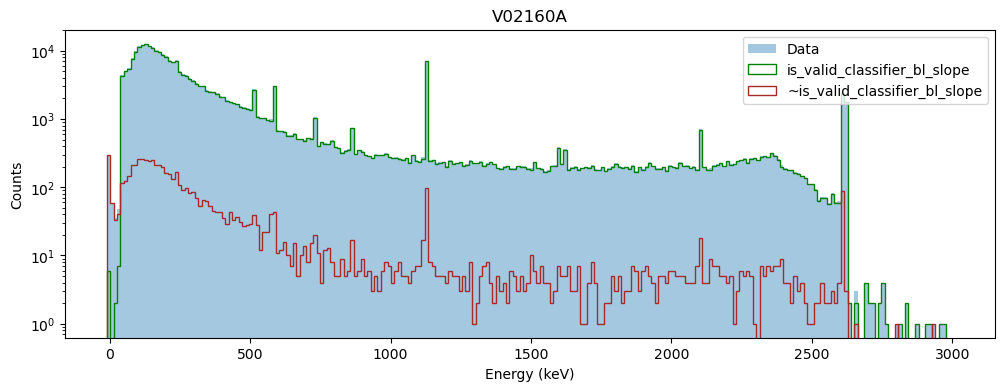

In [28]:
plt.figure(figsize = (12,4))
plt.hist(data["cuspEmax_ctc_cal"], bins = 250, range = (-10, 3000), alpha = 0.4, label = 'Data')
plt.hist(data.query("is_valid_classifier_bl_slope")["cuspEmax_ctc_cal"], color = 'green', bins = 250, range = (-10, 3000), histtype = 'step', label = 'is_valid_classifier_bl_slope')
plt.hist(data.query("~is_valid_classifier_bl_slope")["cuspEmax_ctc_cal"], color = 'brown',bins = 250,  range = (-10, 3000), histtype = 'step', label = '~is_valid_classifier_bl_slope')
#plt.hist(data.query("~is_pulser & is_valid_classifier_bl_slope & is_below_500keV")["cuspEmax_ctc_cal"], bins = 500, range = (-10, 3000), histtype = 'step')
plt.legend(loc = 'upper right')
plt.ylabel(f"Counts")
plt.xlabel(f"Energy (keV)")
plt.title(f"{detector}")
plt.yscale('log')


-----------------

# All channels

In [29]:
from tqdm import tqdm

In [30]:
channels_rawid.keys()

dict_keys(['ICPC', 'BEGe', 'Coax', 'PPC'])

In [31]:

cal = Props.read_from(cal_file)
print(cal.keys())

dict_keys(['ch1104000', 'ch1104001', 'ch1104002', 'ch1104003', 'ch1104004', 'ch1104005', 'ch1105600', 'ch1105602', 'ch1105603', 'ch1107202', 'ch1107203', 'ch1107204', 'ch1107205', 'ch1108800', 'ch1108801', 'ch1108802', 'ch1108803', 'ch1110402', 'ch1110403', 'ch1110404', 'ch1112000', 'ch1112001', 'ch1112002', 'ch1112003', 'ch1112004', 'ch1112005', 'ch1113600', 'ch1113601', 'ch1113602', 'ch1113603', 'ch1113604', 'ch1113605', 'ch1115203', 'ch1115204', 'ch1116801', 'ch1116802', 'ch1116803', 'ch1116804', 'ch1116805', 'ch1118402', 'ch1118403', 'ch1118404', 'ch1118405', 'ch1120000', 'ch1120001', 'ch1120002', 'ch1120003', 'ch1120004', 'ch1120005', 'ch1121600', 'ch1121601', 'ch1121602', 'ch1121603', 'ch1121604', 'ch1121605', 'ch1078400', 'ch1078405', 'ch1080000', 'ch1080001', 'ch1080004', 'ch1080005', 'ch1081600', 'ch1081601', 'ch1081602', 'ch1081603', 'ch1081604', 'ch1081605', 'ch1083201', 'ch1083202', 'ch1083203', 'ch1083204', 'ch1083205', 'ch1084800', 'ch1084801', 'ch1084802', 'ch1084803', '

In [32]:
cal_channels = set(cal.keys())
expected = set(
    channels_rawid['ICPC']
    + channels_rawid['BEGe']
    + channels_rawid['Coax']
    + channels_rawid['PPC']
)
missing = expected - cal_channels
print(sorted(missing))

cal_channels = set(cal.keys())

channels_rawid = {
    det: [ch for ch in ch_list if ch in cal_channels]
    for det, ch_list in channels_rawid.items()
}

['ch1080002', 'ch1080003', 'ch1083200', 'ch1088000', 'ch1088004', 'ch1089602', 'ch1089604', 'ch1108804', 'ch1110405', 'ch1115200', 'ch1115201', 'ch1115202']


## Bege

In [33]:
"""
dfs = []
threshold_masks = {}

start = time.time()
for channel in tqdm(channels_rawid['BEGe']):
    df = load_data(
        files=psp_files,
        lh5_path=f"{channel}/dsp",
        cal_dict=Props.read_from(cal_file)[channel]["pars"]["operations"],
        params=params,
        return_selection_mask=False,
    )
    
    df = df.copy()

    pulser_ids, mask_pulser = get_tcm_pulser_ids(tcm_files, channel, 5) # pulser removal
    df["is_pulser"] = mask_pulser

    dfs.append(df)
    threshold_masks[channel] = mask

data = pd.concat(dfs, ignore_index=True)

print("Took", time.time() - start, "s to read")"""

'\ndfs = []\nthreshold_masks = {}\n\nstart = time.time()\nfor channel in tqdm(channels_rawid[\'BEGe\']):\n    df = load_data(\n        files=psp_files,\n        lh5_path=f"{channel}/dsp",\n        cal_dict=Props.read_from(cal_file)[channel]["pars"]["operations"],\n        params=params,\n        return_selection_mask=False,\n    )\n    \n    df = df.copy()\n\n    pulser_ids, mask_pulser = get_tcm_pulser_ids(tcm_files, channel, 5) # pulser removal\n    df["is_pulser"] = mask_pulser\n\n    dfs.append(df)\n    threshold_masks[channel] = mask\n\ndata = pd.concat(dfs, ignore_index=True)\n\nprint("Took", time.time() - start, "s to read")'

In [34]:
"""mask_discharge = data['t_sat_lo']>0
data["is_discharge"] = mask_discharge


mask_lowe = data["cuspEmax_ctc_cal"] < 500
data["is_below_500keV"] = mask_lowe


classifier = (data["bl_slope"] - a_class) / b_class

mask_class = (classifier > cal_dict["is_valid_bl_slope"]["parameters"]["a"]) & \
       (classifier < cal_dict["is_valid_bl_slope"]["parameters"]["b"])

data["is_valid_classifier_bl_slope"] = mask_class"""

'mask_discharge = data[\'t_sat_lo\']>0\ndata["is_discharge"] = mask_discharge\n\n\nmask_lowe = data["cuspEmax_ctc_cal"] < 500\ndata["is_below_500keV"] = mask_lowe\n\n\nclassifier = (data["bl_slope"] - a_class) / b_class\n\nmask_class = (classifier > cal_dict["is_valid_bl_slope"]["parameters"]["a"]) &        (classifier < cal_dict["is_valid_bl_slope"]["parameters"]["b"])\n\ndata["is_valid_classifier_bl_slope"] = mask_class'

In [35]:
#data.to_parquet("data_BEGE.parquet", index=True)
#import pandas as pd
data = pd.read_parquet("data_BEGE.parquet")

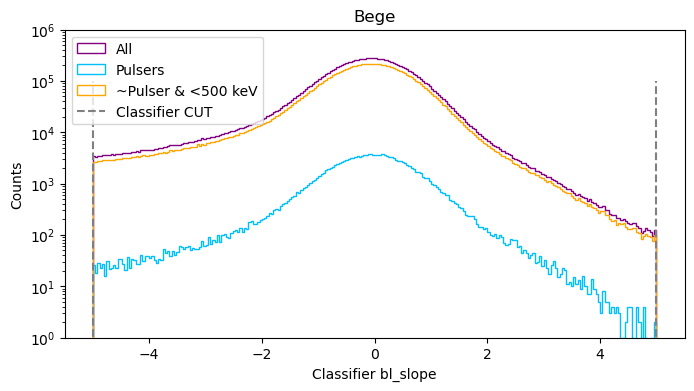

In [36]:

plt.figure(figsize = (8,4))
plt.hist((data.query("is_valid_classifier_bl_slope")["bl_slope"]-a_class)/b_class, bins = 250, range = (-5, 5), color = 'purple', histtype = 'step', label = 'All')
plt.hist((data.query("is_pulser&is_valid_classifier_bl_slope")["bl_slope"]-a_class)/b_class, bins = 250, range = ( -5, 5), color = "deepskyblue", histtype = 'step', label = 'Pulsers')
plt.hist((data.query("~is_pulser&is_below_500keV&is_valid_classifier_bl_slope")["bl_slope"]-a_class)/b_class, bins = 250, range = (-5, 5), color = "orange", histtype = 'step', label = '~Pulser & <500 keV')
#plt.hist((data.query("is_below_500keV")["bl_slope"]-a_class)/b_class, bins = 500, range = (-10,10), histtype = 'step', label = '<500 KeV')
#plt.hist((data.query("~is_pulser")["bl_slope"][e_cal<500]-a_class)/b_class, bins = 500, range = (-1,1), histtype = 'step', label = '< 500 kev')
plt.vlines(-5, 0, 1e5, ls = '--', color = 'grey' )
plt.vlines(5, 0, 1e5, ls = '--', color = 'grey', label = 'Classifier CUT' )
plt.ylim(1, 1e6)
plt.legend(loc = 'upper left')
plt.ylabel(f"Counts")
plt.xlabel(f"Classifier bl_slope")
plt.title(f"Bege")
plt.yscale('log')
plt.savefig("bl_slope_class.svg", dpi = 600)

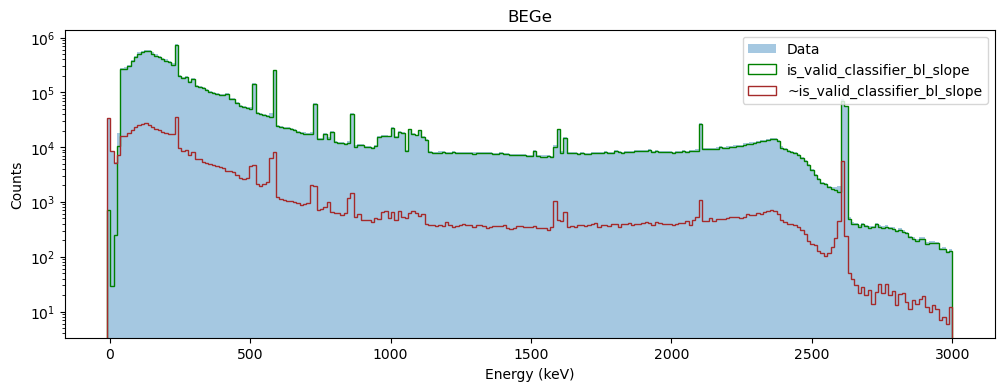

In [37]:
plt.figure(figsize = (12,4))
plt.hist(data["cuspEmax_ctc_cal"], bins = 250, range = (-10, 3000), alpha = 0.4, label = 'Data')
plt.hist(data.query("is_valid_classifier_bl_slope")["cuspEmax_ctc_cal"], color = 'green', bins = 250, range = (-10, 3000), histtype = 'step', label = 'is_valid_classifier_bl_slope')
plt.hist(data.query("~is_valid_classifier_bl_slope")["cuspEmax_ctc_cal"], color = 'brown',bins = 250,  range = (-10, 3000), histtype = 'step', label = '~is_valid_classifier_bl_slope')
#plt.hist(data.query("~is_pulser & is_valid_classifier_bl_slope & is_below_500keV")["cuspEmax_ctc_cal"], bins = 500, range = (-10, 3000), histtype = 'step')
plt.legend(loc = 'upper right')
plt.ylabel(f"Counts")
plt.xlabel(f"Energy (keV)")
plt.title(f"BEGe")
plt.yscale('log')



## Coax


In [80]:
"""dfs = []
threshold_masks = {}

start = time.time()
for channel in tqdm(channels_rawid['Coax']):
    df = load_data(
        files=psp_files,
        lh5_path=f"{channel}/dsp",
        cal_dict=Props.read_from(cal_file)[channel]["pars"]["operations"],
        params=params,
        return_selection_mask=False,
    )
    
    df = df.copy()

    pulser_ids, mask_pulser = get_tcm_pulser_ids(tcm_files, channel, 5) # pulser removal
    df["is_pulser"] = mask_pulser

    dfs.append(df)
    threshold_masks[channel] = mask

data = pd.concat(dfs, ignore_index=True)

print("Took", time.time() - start, "s to read")"""

'dfs = []\nthreshold_masks = {}\n\nstart = time.time()\nfor channel in tqdm(channels_rawid[\'Coax\']):\n    df = load_data(\n        files=psp_files,\n        lh5_path=f"{channel}/dsp",\n        cal_dict=Props.read_from(cal_file)[channel]["pars"]["operations"],\n        params=params,\n        return_selection_mask=False,\n    )\n    \n    df = df.copy()\n\n    pulser_ids, mask_pulser = get_tcm_pulser_ids(tcm_files, channel, 5) # pulser removal\n    df["is_pulser"] = mask_pulser\n\n    dfs.append(df)\n    threshold_masks[channel] = mask\n\ndata = pd.concat(dfs, ignore_index=True)\n\nprint("Took", time.time() - start, "s to read")'

In [81]:
"""mask_discharge = data['t_sat_lo']>0
data["is_discharge"] = mask_discharge


mask_lowe = data["cuspEmax_ctc_cal"] < 500
data["is_below_500keV"] = mask_lowe


classifier = (data["bl_slope"] - a_class) / b_class

mask_class = (classifier > cal_dict["is_valid_bl_slope"]["parameters"]["a"]) & \
       (classifier < cal_dict["is_valid_bl_slope"]["parameters"]["b"])

data["is_valid_classifier_bl_slope"] = mask_class"""

'mask_discharge = data[\'t_sat_lo\']>0\ndata["is_discharge"] = mask_discharge\n\n\nmask_lowe = data["cuspEmax_ctc_cal"] < 500\ndata["is_below_500keV"] = mask_lowe\n\n\nclassifier = (data["bl_slope"] - a_class) / b_class\n\nmask_class = (classifier > cal_dict["is_valid_bl_slope"]["parameters"]["a"]) &        (classifier < cal_dict["is_valid_bl_slope"]["parameters"]["b"])\n\ndata["is_valid_classifier_bl_slope"] = mask_class'

In [61]:
#data.to_parquet("data_COAX.parquet", index=True)
#import pandas as pd
data = pd.read_parquet("data_COAX.parquet")

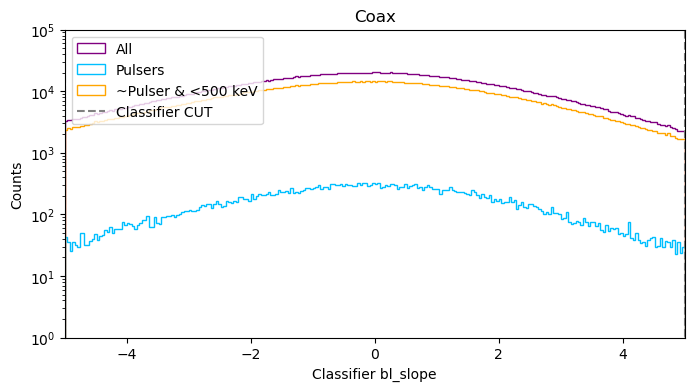

In [66]:

plt.figure(figsize = (8,4))
plt.hist((data.query("is_valid_classifier_bl_slope")["bl_slope"]-a_class)/b_class, bins = 250, range = (-5, 5), color = 'purple', histtype = 'step', label = 'All')
plt.hist((data.query("is_pulser&is_valid_classifier_bl_slope")["bl_slope"]-a_class)/b_class, bins = 250, range = ( -5, 5), color = "deepskyblue", histtype = 'step', label = 'Pulsers')
plt.hist((data.query("~is_pulser&is_below_500keV&is_valid_classifier_bl_slope")["bl_slope"]-a_class)/b_class, bins = 250, range = (-5, 5), color = "orange", histtype = 'step', label = '~Pulser & <500 keV')
#plt.hist((data.query("is_below_500keV")["bl_slope"]-a_class)/b_class, bins = 500, range = (-10,10), histtype = 'step', label = '<500 KeV')
#plt.hist((data.query("~is_pulser")["bl_slope"][e_cal<500]-a_class)/b_class, bins = 500, range = (-1,1), histtype = 'step', label = '< 500 kev')
plt.vlines(-5, 0, 1e5, ls = '--', color = 'grey' )
plt.vlines(5, 0, 1e5, ls = '--', color = 'grey', label = 'Classifier CUT' )
plt.ylim(1, 1e5)
plt.xlim(-5, 5)
plt.legend(loc = 'upper left')
plt.ylabel(f"Counts")
plt.xlabel(f"Classifier bl_slope")
plt.title(f"Coax")
plt.yscale('log')
plt.savefig("bl_slope_class.svg", dpi = 600)

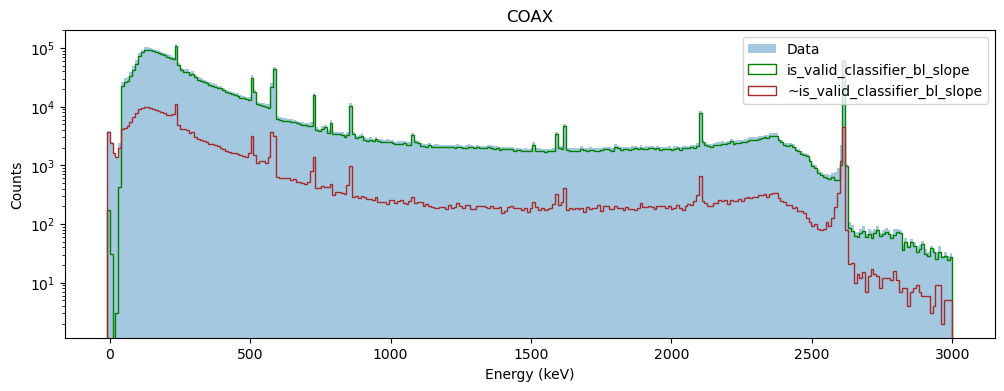

In [63]:
plt.figure(figsize = (12,4))
plt.hist(data.query('~is_pulser&~is_discharge')["cuspEmax_ctc_cal"], bins = 300, range = (-10, 3000), alpha = 0.4, label = 'Data')
plt.hist(data.query("~is_pulser&~is_discharge&is_valid_classifier_bl_slope")["cuspEmax_ctc_cal"], color = 'green', bins = 300, range = (-10, 3000), histtype = 'step', label = 'is_valid_classifier_bl_slope')
plt.hist(data.query("~is_pulser&~is_discharge&~is_valid_classifier_bl_slope")["cuspEmax_ctc_cal"], color = 'brown',bins = 300,  range = (-10, 3000), histtype = 'step', label = '~is_valid_classifier_bl_slope')
plt.legend(loc = 'upper right')
plt.ylabel(f"Counts")
plt.xlabel(f"Energy (keV)")
plt.title(f"COAX")
plt.yscale('log')





# ICPC

In [82]:
"""fs = []
threshold_masks = {}

start = time.time()
for channel in tqdm(channels_rawid['ICPC']):
    df = load_data(
        files=psp_files,
        lh5_path=f"{channel}/dsp",
        cal_dict=Props.read_from(cal_file)[channel]["pars"]["operations"],
        params=params,
        return_selection_mask=False,
    )
    
    df = df.copy()

    pulser_ids, mask_pulser = get_tcm_pulser_ids(tcm_files, channel, 5) # pulser removal
    df["is_pulser"] = mask_pulser

    dfs.append(df)
    threshold_masks[channel] = mask

data = pd.concat(dfs, ignore_index=True)

print("Took", time.time() - start, "s to read")"""

'fs = []\nthreshold_masks = {}\n\nstart = time.time()\nfor channel in tqdm(channels_rawid[\'ICPC\']):\n    df = load_data(\n        files=psp_files,\n        lh5_path=f"{channel}/dsp",\n        cal_dict=Props.read_from(cal_file)[channel]["pars"]["operations"],\n        params=params,\n        return_selection_mask=False,\n    )\n    \n    df = df.copy()\n\n    pulser_ids, mask_pulser = get_tcm_pulser_ids(tcm_files, channel, 5) # pulser removal\n    df["is_pulser"] = mask_pulser\n\n    dfs.append(df)\n    threshold_masks[channel] = mask\n\ndata = pd.concat(dfs, ignore_index=True)\n\nprint("Took", time.time() - start, "s to read")'

In [83]:
"""mask_discharge = data['t_sat_lo']>0
data["is_discharge"] = mask_discharge


mask_lowe = data["cuspEmax_ctc_cal"] < 500
data["is_below_500keV"] = mask_lowe


classifier = (data["bl_slope"] - a_class) / b_class

mask_class = (classifier > cal_dict["is_valid_bl_slope"]["parameters"]["a"]) & \
       (classifier < cal_dict["is_valid_bl_slope"]["parameters"]["b"])

data["is_valid_classifier_bl_slope"] = mask_class"""

'mask_discharge = data[\'t_sat_lo\']>0\ndata["is_discharge"] = mask_discharge\n\n\nmask_lowe = data["cuspEmax_ctc_cal"] < 500\ndata["is_below_500keV"] = mask_lowe\n\n\nclassifier = (data["bl_slope"] - a_class) / b_class\n\nmask_class = (classifier > cal_dict["is_valid_bl_slope"]["parameters"]["a"]) &        (classifier < cal_dict["is_valid_bl_slope"]["parameters"]["b"])\n\ndata["is_valid_classifier_bl_slope"] = mask_class'

In [1]:
#data.to_parquet("data_ICPC.parquet", index=True)
#import pandas as pd

data = pd.read_parquet("data_ICPC.parquet")

NameError: name 'pd' is not defined

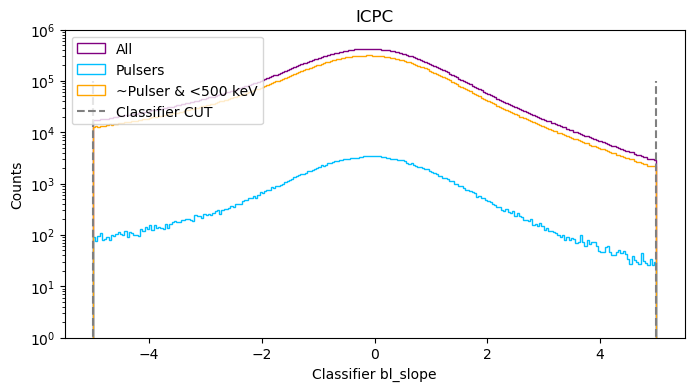

In [60]:

plt.figure(figsize = (8,4))
plt.hist((data.query("is_valid_classifier_bl_slope&~is_discharge")["bl_slope"]-a_class)/b_class, bins = 250, range = (-5, 5), color = 'purple', histtype = 'step', label = 'All')
plt.hist((data.query("is_pulser&is_valid_classifier_bl_slope&~is_discharge")["bl_slope"]-a_class)/b_class, bins = 250, range = ( -5, 5), color = "deepskyblue", histtype = 'step', label = 'Pulsers')
plt.hist((data.query("~is_pulser&is_below_500keV&is_valid_classifier_bl_slope&~is_discharge")["bl_slope"]-a_class)/b_class, bins = 250, range = (-5, 5), color = "orange", histtype = 'step', label = '~Pulser & <500 keV')
#plt.hist((data.query("is_below_500keV")["bl_slope"]-a_class)/b_class, bins = 500, range = (-10,10), histtype = 'step', label = '<500 KeV')
#plt.hist((data.query("~is_pulser")["bl_slope"][e_cal<500]-a_class)/b_class, bins = 500, range = (-1,1), histtype = 'step', label = '< 500 kev')
plt.vlines(-5, 0, 1e5, ls = '--', color = 'grey' )
plt.vlines(5, 0, 1e5, ls = '--', color = 'grey', label = 'Classifier CUT' )
plt.ylim(1, 1e6)
plt.legend(loc = 'upper left')
plt.ylabel(f"Counts")
plt.xlabel(f"Classifier bl_slope")
plt.title(f"ICPC")
plt.yscale('log')
plt.savefig("bl_slope_class.svg", dpi = 600)

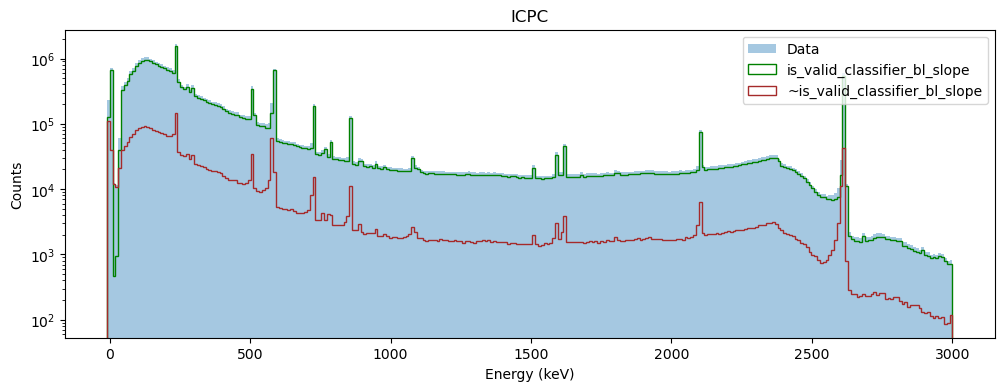

In [59]:
plt.figure(figsize = (12,4))
plt.hist(data.query('~is_pulser&~is_discharge')["cuspEmax_ctc_cal"], bins = 300, range = (-10, 3000), alpha = 0.4, label = 'Data')
plt.hist(data.query("~is_pulser&~is_discharge&is_valid_classifier_bl_slope")["cuspEmax_ctc_cal"], color = 'green', bins = 300, range = (-10, 3000), histtype = 'step', label = 'is_valid_classifier_bl_slope')
plt.hist(data.query("~is_pulser&~is_discharge&~is_valid_classifier_bl_slope")["cuspEmax_ctc_cal"], color = 'brown',bins = 300,  range = (-10, 3000), histtype = 'step', label = '~is_valid_classifier_bl_slope')
plt.legend(loc = 'upper right')
plt.ylabel(f"Counts")
plt.xlabel(f"Energy (keV)")
plt.title(f"ICPC")
plt.yscale('log')



# PPC

In [84]:
"""dfs = []
threshold_masks = {}

start = time.time()
for channel in tqdm(channels_rawid['PPC']):
    df = load_data(
        files=psp_files,
        lh5_path=f"{channel}/dsp",
        cal_dict=Props.read_from(cal_file)[channel]["pars"]["operations"],
        params=params,
        return_selection_mask=False,
    )
    
    df = df.copy()

    pulser_ids, mask_pulser = get_tcm_pulser_ids(tcm_files, channel, 5) # pulser removal
    df["is_pulser"] = mask_pulser

    dfs.append(df)
    threshold_masks[channel] = mask

data = pd.concat(dfs, ignore_index=True)

print("Took", time.time() - start, "s to read")"""

'dfs = []\nthreshold_masks = {}\n\nstart = time.time()\nfor channel in tqdm(channels_rawid[\'PPC\']):\n    df = load_data(\n        files=psp_files,\n        lh5_path=f"{channel}/dsp",\n        cal_dict=Props.read_from(cal_file)[channel]["pars"]["operations"],\n        params=params,\n        return_selection_mask=False,\n    )\n    \n    df = df.copy()\n\n    pulser_ids, mask_pulser = get_tcm_pulser_ids(tcm_files, channel, 5) # pulser removal\n    df["is_pulser"] = mask_pulser\n\n    dfs.append(df)\n    threshold_masks[channel] = mask\n\ndata = pd.concat(dfs, ignore_index=True)\n\nprint("Took", time.time() - start, "s to read")'

In [85]:
"""mask_discharge = data['t_sat_lo']>0
data["is_discharge"] = mask_discharge


mask_lowe = data["cuspEmax_ctc_cal"] < 500
data["is_below_500keV"] = mask_lowe


classifier = (data["bl_slope"] - a_class) / b_class

mask_class = (classifier > cal_dict["is_valid_bl_slope"]["parameters"]["a"]) & \
       (classifier < cal_dict["is_valid_bl_slope"]["parameters"]["b"])

data["is_valid_classifier_bl_slope"] = mask_class"""

'mask_discharge = data[\'t_sat_lo\']>0\ndata["is_discharge"] = mask_discharge\n\n\nmask_lowe = data["cuspEmax_ctc_cal"] < 500\ndata["is_below_500keV"] = mask_lowe\n\n\nclassifier = (data["bl_slope"] - a_class) / b_class\n\nmask_class = (classifier > cal_dict["is_valid_bl_slope"]["parameters"]["a"]) &        (classifier < cal_dict["is_valid_bl_slope"]["parameters"]["b"])\n\ndata["is_valid_classifier_bl_slope"] = mask_class'

In [71]:
#data.to_parquet("data_PPC.parquet", index=True)
#import pandas as pd

data = pd.read_parquet("data_PPC.parquet")

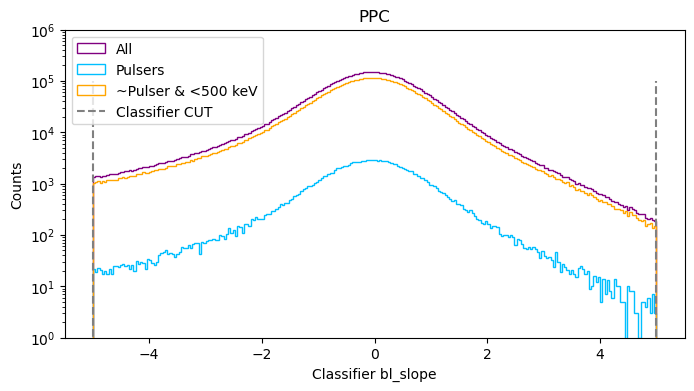

In [73]:

plt.figure(figsize = (8,4))
plt.hist((data.query("is_valid_classifier_bl_slope")["bl_slope"]-a_class)/b_class, bins = 250, range = (-5, 5), color = 'purple', histtype = 'step', label = 'All')
plt.hist((data.query("is_pulser&is_valid_classifier_bl_slope")["bl_slope"]-a_class)/b_class, bins = 250, range = ( -5, 5), color = "deepskyblue", histtype = 'step', label = 'Pulsers')
plt.hist((data.query("~is_pulser&is_below_500keV&is_valid_classifier_bl_slope")["bl_slope"]-a_class)/b_class, bins = 250, range = (-5, 5), color = "orange", histtype = 'step', label = '~Pulser & <500 keV')
#plt.hist((data.query("is_below_500keV")["bl_slope"]-a_class)/b_class, bins = 500, range = (-10,10), histtype = 'step', label = '<500 KeV')
#plt.hist((data.query("~is_pulser")["bl_slope"][e_cal<500]-a_class)/b_class, bins = 500, range = (-1,1), histtype = 'step', label = '< 500 kev')
plt.vlines(-5, 0, 1e5, ls = '--', color = 'grey' )
plt.vlines(5, 0, 1e5, ls = '--', color = 'grey', label = 'Classifier CUT' )
plt.ylim(1, 1e6)
plt.legend(loc = 'upper left')
plt.ylabel(f"Counts")
plt.xlabel(f"Classifier bl_slope")
plt.title(f"PPC")
plt.yscale('log')
plt.savefig("bl_slope_class.svg", dpi = 600)

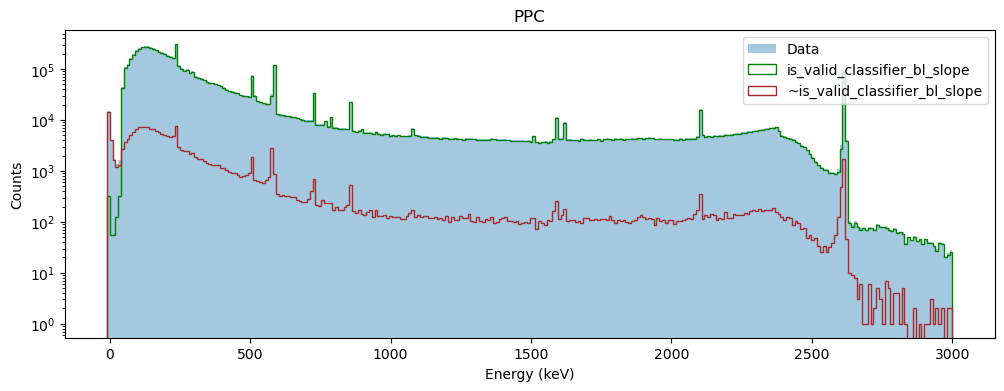

In [74]:
plt.figure(figsize = (12,4))
plt.hist(data.query('~is_pulser&~is_discharge')["cuspEmax_ctc_cal"], bins = 300, range = (-10, 3000), alpha = 0.4, label = 'Data')
plt.hist(data.query("~is_pulser&~is_discharge&is_valid_classifier_bl_slope")["cuspEmax_ctc_cal"], color = 'green', bins = 300, range = (-10, 3000), histtype = 'step', label = 'is_valid_classifier_bl_slope')
plt.hist(data.query("~is_pulser&~is_discharge&~is_valid_classifier_bl_slope")["cuspEmax_ctc_cal"], color = 'brown',bins = 300,  range = (-10, 3000), histtype = 'step', label = '~is_valid_classifier_bl_slope')
plt.legend(loc = 'upper right')
plt.ylabel(f"Counts")
plt.xlabel(f"Energy (keV)")
plt.title(f"PPC")
plt.yscale('log')

